# 03 — Point-in-time alignment

Read-only: imports from `src.point_in_time` and `scripts.verify_alignment` (which itself only reads `data/processed/`).

Three alignments are compared throughout:
- **`weekly`** (primary) — retail Monday snapshot paired with the prior weekly-Friday crude observation.
- **`daily_pit`** (robustness) — retail Monday paired with the prior trading day's daily close (usually Friday).
- **`leaky`** (contrast only) — retail Monday paired with the *same-week* Friday, via `direction="forward"`. This one is deliberately wrong; it exists to show what the guard in `src/point_in_time.py` prevents.

In [3]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm


def find_repo_root(start: Path) -> Path:
    """Walk upward from `start` until a directory containing pyproject.toml is found."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("no pyproject.toml found in any parent directory")

REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.point_in_time import align_retail_to_upstream
from scripts.verify_alignment import PROCESSED_DIR, RETAIL_SERIES_ID, UPSTREAM_SERIES_ID, leaky_merge, load_series

# UPSTREAM_SERIES_ID ("WCOILWTICO") is the WEEKLY crude series' own ID — the daily series
# is a genuinely different FRED series, DCOILWTICO, not the same ID at a different freq.
DAILY_UPSTREAM_SERIES_ID = "DCOILWTICO"

COLOR_WEEKLY = "#2a78d6"
COLOR_DAILY_PIT = "#1baf7a"
COLOR_LEAKY = "#eb6834"
COLOR_RETAIL = "#eb6834"

retail_full = load_series(PROCESSED_DIR / "retail.csv", RETAIL_SERIES_ID, "weekly-mon")
weekly_upstream = load_series(PROCESSED_DIR / "crude.csv", UPSTREAM_SERIES_ID, "weekly-fri")
daily_upstream_raw = load_series(PROCESSED_DIR / "crude.csv", DAILY_UPSTREAM_SERIES_ID, "daily")

# FRED's daily series has a row for every weekday, including market holidays — those rows
# carry a NaN value rather than being omitted (confirmed directly against the raw table:
# Good Friday 2024-03-29 has a row, value NaN). Dropping NaN before merging is required for
# daily_pit — without it, a backward asof search could land ON a holiday's NaN row instead
# of correctly skipping past it to the last real close.
daily_upstream = daily_upstream_raw.dropna(subset=["value"]).reset_index(drop=True)
print(f"daily upstream: {len(daily_upstream_raw)} rows pulled, {daily_upstream_raw['value'].isna().sum()} holiday NaNs dropped -> {len(daily_upstream)} usable")

# Boundary case, found by actually running this: retail's first date (2010-01-04) exactly
# coincides with daily_upstream's earliest available date — this project pulls from
# 2010-01-01 onward (fetch_series.START_DATE), so there is no daily close strictly before
# retail's very first Monday within the pulled window. align_retail_to_upstream correctly
# raises on that row (a real "no valid point-in-time match" case, not a leak). Trimming
# retail once, here, keeps weekly/daily_pit/leaky all built from the identical, safe date
# range — required for section 2c's row-for-row comparison to be meaningful.
retail = retail_full[retail_full["date"] > daily_upstream["date"].min()].reset_index(drop=True)
print(f"retail: {len(retail_full)} -> {len(retail)} rows after trimming the one date with no valid daily_pit lookback")

weekly = align_retail_to_upstream(retail, weekly_upstream, mode="weekly")
daily_pit = align_retail_to_upstream(retail, daily_upstream, mode="daily_pit")
leaky = leaky_merge(retail, weekly_upstream)
leaky["gap_days"] = (leaky["date"] - leaky["upstream_date"]).dt.days

ALIGNMENTS = {"weekly": weekly, "daily_pit": daily_pit, "leaky": leaky}
ALIGNMENT_COLORS = {"weekly": COLOR_WEEKLY, "daily_pit": COLOR_DAILY_PIT, "leaky": COLOR_LEAKY}

for name, df in ALIGNMENTS.items():
    print(f"{name:<10} {len(df)} rows, {df['value_upstream'].isna().sum()} unmatched")

daily upstream: 4327 rows pulled, 168 holiday NaNs dropped -> 4159 usable
retail: 866 -> 865 rows after trimming the one date with no valid daily_pit lookback
weekly     865 rows, 0 unmatched
daily_pit  865 rows, 0 unmatched
leaky      865 rows, 1 unmatched


## 1. One worked example
A single retail Monday, shown two ways: the row `align_retail_to_upstream` actually produced (weekly, prior-week Friday), next to the row a leaky same-week join would have produced for that same Monday. Same retail date and value on both sides — only `upstream_date`, `value_upstream`, and the implied gap differ.

**What this shows:** concretely, in one row, what "same-week Friday" vs. "prior-week Friday" actually means as a date and a price — not just as a rule in prose.

In [7]:
EXAMPLE_DATE = pd.Timestamp("2022-06-13")  # a Monday during the 2022 crude spike — upstream moving fast that week

weekly_row = weekly[weekly["date"] == EXAMPLE_DATE].iloc[0]
leaky_row = leaky[leaky["date"] == EXAMPLE_DATE].iloc[0]

comparison = pd.DataFrame(
    {
        "weekly (prior week's Friday)": [weekly_row["date"].date(), weekly_row["upstream_date"].date(), weekly_row["value_upstream"], int(weekly_row["gap_days"])],
        "leaky (same week's Friday)": [leaky_row["date"].date(), leaky_row["upstream_date"].date(), leaky_row["value_upstream"], int(-leaky_row["gap_days"])],
    },
    index=["retail_date", "upstream_date", "value_upstream", "gap_days (retail - upstream)"],
)
comparison

,weekly (prior week's Friday),leaky (same week's Friday)
retail_date,2022-06-13,2022-06-13
upstream_date,2022-06-10,2022-06-17
value_upstream,2.867381,2.772857
gap_days (retail - upstream),3,4


## 2. Three alignments compared
The same evidence ADR-0002 relies on, now with a robustness alignment (`daily_pit`) alongside the primary (`weekly`) and the contrast case (`leaky`).

### 2a. Lag profile
For each alignment: corr(Δretail_t, Δupstream_{t−k}) for k = 0…8, plotted as three lines (markers at each point, each peak annotated), then the same numbers as a table.

**What this shows:** *where* the peak sits, not how high it is. A clean alignment (`weekly`, `daily_pit`) should peak at lag 0 — the upstream observation it paired is genuinely contemporaneous with the survey. `leaky` should peak at lag 1 instead: it paired each Monday with a Friday that is really *next* week's clean value, so the real relationship only lines up once you shift it back by one step — the signal displaced by exactly the week it leaked.

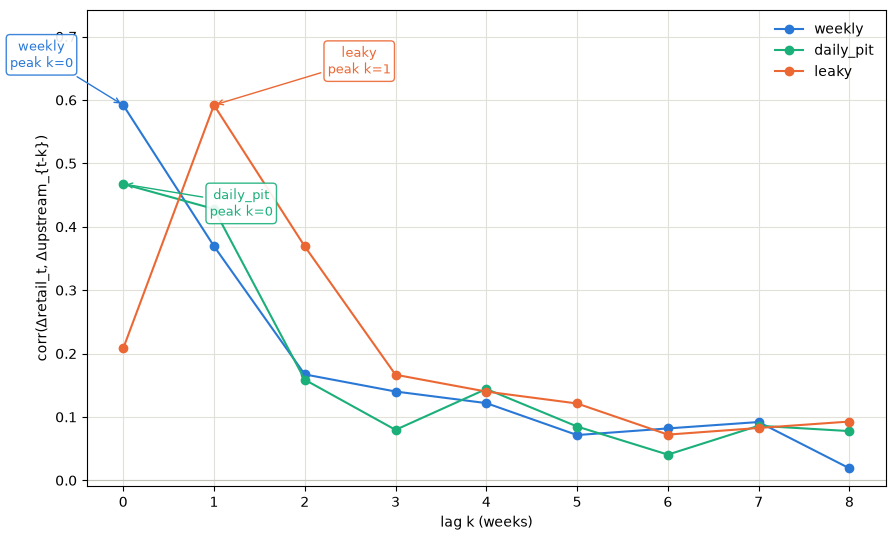

In [3]:
MAX_LAG = 8


def lag_correlation(merged: pd.DataFrame, k: int) -> float:
    """corr(delta_retail_t, delta_upstream_{t-k}) — shifting delta_upstream forward by k
    rows makes position t hold what was originally at t-k, so this is exactly the lagged
    correlation the profile needs, for any of the three alignments' merged tables.
    """
    delta_retail = merged["value_retail"].diff()
    delta_upstream = merged["value_upstream"].diff()
    return delta_retail.corr(delta_upstream.shift(k))


lag_table = pd.DataFrame(
    {name: [lag_correlation(df, k) for k in range(MAX_LAG + 1)] for name, df in ALIGNMENTS.items()},
    index=pd.RangeIndex(MAX_LAG + 1, name="lag"),
)

fig, ax = plt.subplots(figsize=(9, 5.5))
for name in ALIGNMENTS:
    ax.plot(lag_table.index, lag_table[name], marker="o", color=ALIGNMENT_COLORS[name], label=name)

# Distinct offsets per series so labels don't collide — weekly's and leaky's peaks land
# at nearly the same height (0.592) at different lags, so a uniform offset overlapped them.
peak_annotation_offsets = {"weekly": (-0.9, 0.06), "daily_pit": (1.3, -0.05), "leaky": (1.6, 0.05)}
for name in ALIGNMENTS:
    peak_lag = lag_table[name].idxmax()
    peak_value = lag_table[name].max()
    dx, dy = peak_annotation_offsets[name]
    ax.annotate(
        f"{name}\npeak k={peak_lag}",
        xy=(peak_lag, peak_value),
        xytext=(peak_lag + dx, peak_value + dy),
        color=ALIGNMENT_COLORS[name],
        fontsize=9,
        ha="center",
        arrowprops={"arrowstyle": "->", "color": ALIGNMENT_COLORS[name], "lw": 1},
        bbox={"boxstyle": "round", "fc": "white", "ec": ALIGNMENT_COLORS[name], "alpha": 0.9},
    )

ax.set_xlabel("lag k (weeks)")
ax.set_ylabel("corr(Δretail_t, Δupstream_{t-k})")
ax.set_xticks(range(MAX_LAG + 1))
ax.set_ylim(top=lag_table.values.max() + 0.15)
ax.grid(True, color="#e1e0d9")
ax.axhline(0, color="#c3c2b7", linewidth=0.8)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [4]:
lag_table.round(3)

,weekly,daily_pit,leaky
lag,,,
0,0.592,0.468,0.208
1,0.369,0.428,0.592
2,0.167,0.159,0.369
3,0.140,0.080,0.167
4,0.122,0.144,0.140
5,0.071,0.085,0.121
6,0.082,0.041,0.072
7,0.092,0.086,0.083
8,0.019,0.078,0.093


### 2b. Scatter plot
Three panels, identical x and y limits: raw Δretail-vs-Δcrude points at alpha=0.25 (background), an OLS fitted line, and 20 equal-count bins of Δcrude with the mean Δretail in each bin, drawn as larger markers. Correlation and fitted slope in each title.

**What this shows:** the binned means are the point — with 864-865 raw points per panel, the cloud alone is hard to read by eye; collapsing it to 20 bin-means makes the actual shape of the relationship (and how it differs across the three alignments) legible.

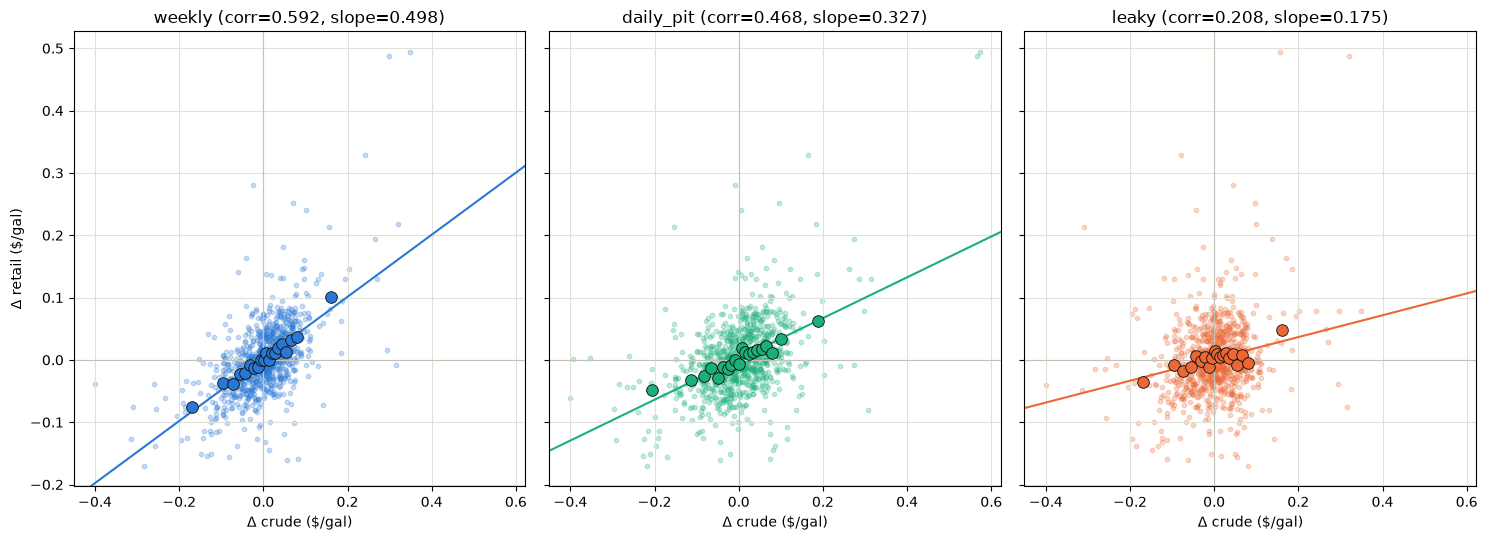

In [5]:
N_BINS = 20


def compute_deltas(merged: pd.DataFrame) -> pd.DataFrame:
    """Δupstream/Δretail as one frame, NaN-dropped jointly (not column-by-column) so the
    two series never desync — leaky in particular carries a real NaN (its final row has
    no forward match), and dropping each column's NaN independently would silently
    misalign dx against dy by one position.
    """
    return pd.DataFrame({"dx": merged["value_upstream"].diff(), "dy": merged["value_retail"].diff()}).dropna()


deltas_by_alignment = {name: compute_deltas(df) for name, df in ALIGNMENTS.items()}

all_dx = pd.concat([d["dx"] for d in deltas_by_alignment.values()])
all_dy = pd.concat([d["dy"] for d in deltas_by_alignment.values()])
x_pad = (all_dx.max() - all_dx.min()) * 0.05
y_pad = (all_dy.max() - all_dy.min()) * 0.05
shared_xlim = (all_dx.min() - x_pad, all_dx.max() + x_pad)
shared_ylim = (all_dy.min() - y_pad, all_dy.max() + y_pad)

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), sharex=True, sharey=True)

for ax, name in zip(axes, ALIGNMENTS):
    deltas = deltas_by_alignment[name]
    color = ALIGNMENT_COLORS[name]

    ax.scatter(deltas["dx"], deltas["dy"], s=10, alpha=0.25, color=color)

    model = sm.OLS(deltas["dy"], sm.add_constant(deltas["dx"])).fit()
    intercept, slope = model.params.iloc[0], model.params.iloc[1]
    line_x = np.array(shared_xlim)
    ax.plot(line_x, intercept + slope * line_x, color=color, linewidth=1.5)

    bins = pd.qcut(deltas["dx"], q=N_BINS, duplicates="drop")
    binned = deltas.groupby(bins, observed=True).mean()
    ax.scatter(binned["dx"], binned["dy"], s=70, color=color, edgecolor="#0b0b0b", linewidth=0.6, zorder=5)

    corr = deltas["dx"].corr(deltas["dy"])
    ax.set_title(f"{name} (corr={corr:.3f}, slope={slope:.3f})")
    ax.set_xlabel("Δ crude ($/gal)")
    ax.grid(True, color="#e1e0d9")
    ax.axhline(0, color="#c3c2b7", linewidth=0.8)
    ax.axvline(0, color="#c3c2b7", linewidth=0.8)

axes[0].set_ylabel("Δ retail ($/gal)")
axes[0].set_xlim(shared_xlim)
axes[0].set_ylim(shared_ylim)
plt.tight_layout()
plt.show()

A single week's Δcrude reaches roughly -0.40 to +0.35 $/gal on this data — the extreme low end is the week of 2020-04-24, whose Mon–Fri average absorbed WTI's historic negative-price day (2020-04-20, -$36.98/barrel). Worth knowing before reading too much into the leftmost raw points in any panel above.

### 2c. Weekly vs. daily
`value_upstream` from `weekly` against `value_upstream` from `daily_pit`, for the same retail dates, with a 45° reference line. Correlation and mean absolute difference printed below.

**What this shows:** the measurement-error-vs-timing tradeoff made concrete — `weekly` is a 5-day average (smoother, but blends in days that hadn't happened relative to *other* weeks' surveys the same way); `daily_pit` is a single point-in-time close (sharper timing, noisier value). If the two were identical this would be a perfect line on the diagonal; the actual scatter around that line is the size of that tradeoff, in real dollars.

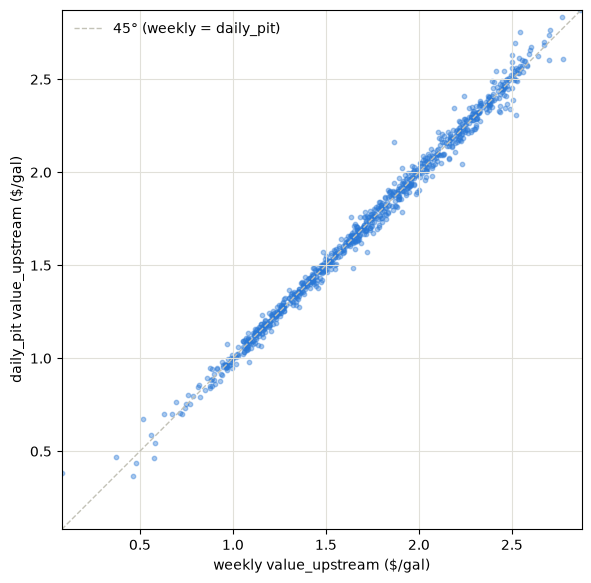

In [6]:
weekly_vs_daily = weekly[["date", "value_upstream"]].merge(
    daily_pit[["date", "value_upstream"]], on="date", suffixes=("_weekly", "_daily_pit")
)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(weekly_vs_daily["value_upstream_weekly"], weekly_vs_daily["value_upstream_daily_pit"], s=10, alpha=0.4, color="#2a78d6")

lims = [
    min(weekly_vs_daily["value_upstream_weekly"].min(), weekly_vs_daily["value_upstream_daily_pit"].min()),
    max(weekly_vs_daily["value_upstream_weekly"].max(), weekly_vs_daily["value_upstream_daily_pit"].max()),
]
ax.plot(lims, lims, color="#c3c2b7", linewidth=1, linestyle="--", label="45° (weekly = daily_pit)")

ax.set_xlabel("weekly value_upstream ($/gal)")
ax.set_ylabel("daily_pit value_upstream ($/gal)")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
ax.grid(True, color="#e1e0d9")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

In [7]:
corr = weekly_vs_daily["value_upstream_weekly"].corr(weekly_vs_daily["value_upstream_daily_pit"])
mad = (weekly_vs_daily["value_upstream_weekly"] - weekly_vs_daily["value_upstream_daily_pit"]).abs().mean()

print(f"n = {len(weekly_vs_daily)}")
print(f"correlation: {corr:.4f}")
print(f"mean absolute difference: {mad:.4f} $/gal")

n = 865
correlation: 0.9962
mean absolute difference: 0.0296 $/gal


## 3. Gap distribution
`gap_days.value_counts()` for each of the three alignments, then every `weekly`/`daily_pit` row where the gap isn't 3 (the ordinary Friday-to-Monday span), with its date — so any holiday-driven shifts can be named directly.

**What this shows:** `weekly`'s gap should be a constant 3 (FRED's weekly series is Friday-labeled every week regardless of holidays — confirmed directly: even Good Friday 2024-03-29 has a real, non-null weekly value). `daily_pit`'s gap should mostly be 3, with occasional 4s and 5s where a market holiday shifted the last trading day back. `leaky`'s gap (defined the same way, `date - upstream_date`) should be uniformly **negative** — the upstream date it paired is in the future relative to the survey, which is exactly the leak.

In [11]:
for name, df in ALIGNMENTS.items():
    print(f"--- {name} ---")
    print(df["gap_days"].value_counts(dropna=False).sort_index())
    print()

--- weekly ---
gap_days
3    865
Name: count, dtype: int64

--- daily_pit ---
gap_days
3    831
4     30
5      4
Name: count, dtype: int64

--- leaky ---
gap_days
-4.0    864
 NaN      1
Name: count, dtype: int64



In [12]:
irregular_weekly = weekly[weekly["gap_days"] != 3][["date", "upstream_date", "gap_days"]]
print(f"weekly: {len(irregular_weekly)} rows with gap_days != 3")
irregular_weekly

weekly: 0 rows with gap_days != 3


,date,upstream_date,gap_days


In [10]:
irregular_daily_pit = daily_pit[daily_pit["gap_days"] != 3][["date", "upstream_date", "gap_days"]]
print(f"daily_pit: {len(irregular_daily_pit)} rows with gap_days != 3")
irregular_daily_pit

daily_pit: 34 rows with gap_days != 3


,date,upstream_date,gap_days
12,2010-04-05,2010-04-01,4
50,2010-12-27,2010-12-23,4
67,2011-04-25,2011-04-21,4
117,2012-04-09,2012-04-05,4
168,2013-04-01,2013-03-28,4
223,2014-04-21,2014-04-17,4
234,2014-07-07,2014-07-03,4
273,2015-04-06,2015-04-02,4
286,2015-07-06,2015-07-02,4
311,2015-12-28,2015-12-24,4


The `daily_pit` gap=4 dates cluster in early April (around Good Friday) and late December (Christmas week); the gap=5 dates are all late November (Thanksgiving Thursday plus a quiet Friday after it) and one early July (Independence Day week) — recognizable from the dates themselves, not asserted here.

## 4. The guard firing
The actual leaky alignment already built above (`leaky`, real same-week-Friday pairings) fed directly into `align_retail_to_upstream`'s internal look-ahead guard, inside a `try`/`except`, printing the real error message.

**Why not just call `align_retail_to_upstream` again with bad input?** `align_retail_to_upstream`'s own `merge_asof(direction="backward")` call can't actually *construct* a same-week-Friday leak — a backward search only ever looks earlier in time or finds nothing at all, so there's no live-code path through the public function that produces `upstream_date > date`. To demonstrate the guard catching the *specific* leak this whole notebook is about, this cell calls the internal guard directly on the already-leaky `leaky` DataFrame — the same technique `tests/test_point_in_time.py::test_leaky_alignment_raises` uses.

**Note on exception type:** the guards in `src/point_in_time.py` raise `ValueError`, not `AssertionError` (flagged the same way when the test suite was written). This cell catches what the code actually raises.

**What this shows:** the guard actually stopping the real leaky data, with its real message and the real offending rows — not just that the guard exists in the source, per ADR-0002: "a safety check never observed to fire is not known to work."

In [11]:
from src.point_in_time import _check_no_look_ahead

print(f"upstream_date >= date (or NaT) on {(~(leaky['upstream_date'] < leaky['date'])).sum()} of {len(leaky)} rows")

try:
    _check_no_look_ahead(leaky)
    print("no error raised — unexpected, since `leaky` should violate the guard on nearly every row")
except ValueError as exc:
    print(f"{type(exc).__name__}: {exc}")

upstream_date >= date (or NaT) on 865 of 865 rows
ValueError: point_in_time.align_retail_to_upstream: found rows where upstream_date is not strictly before the retail date — either a look-ahead leak or no upstream match at all (NaT):
         date upstream_date
0  2010-01-11    2010-01-15
1  2010-01-18    2010-01-22
2  2010-01-25    2010-01-29
3  2010-02-01    2010-02-05
4  2010-02-08    2010-02-12
5  2010-02-15    2010-02-19
6  2010-02-22    2010-02-26
7  2010-03-01    2010-03-05
8  2010-03-08    2010-03-12
9  2010-03-15    2010-03-19
10 2010-03-22    2010-03-26
11 2010-03-29    2010-04-02
12 2010-04-05    2010-04-09
13 2010-04-12    2010-04-16
14 2010-04-19    2010-04-23
15 2010-04-26    2010-04-30
16 2010-05-03    2010-05-07
17 2010-05-10    2010-05-14
18 2010-05-17    2010-05-21
19 2010-05-24    2010-05-28
... (845 more rows not shown, 865 total)


## 5. Timeline
Retail and **both** upstream series (`weekly` and `daily_pit`) on one axis for a six-month window, with vertical lines marking one survey Monday, the weekly-paired upstream date, and the daily_pit-paired upstream date.

**What this shows:** the two clean alignments in their natural context, side by side — how far back "the most recent upstream observation before the survey" reaches on the calendar for each, and how much the daily series actually moves *within* a single week that the weekly average smooths over.

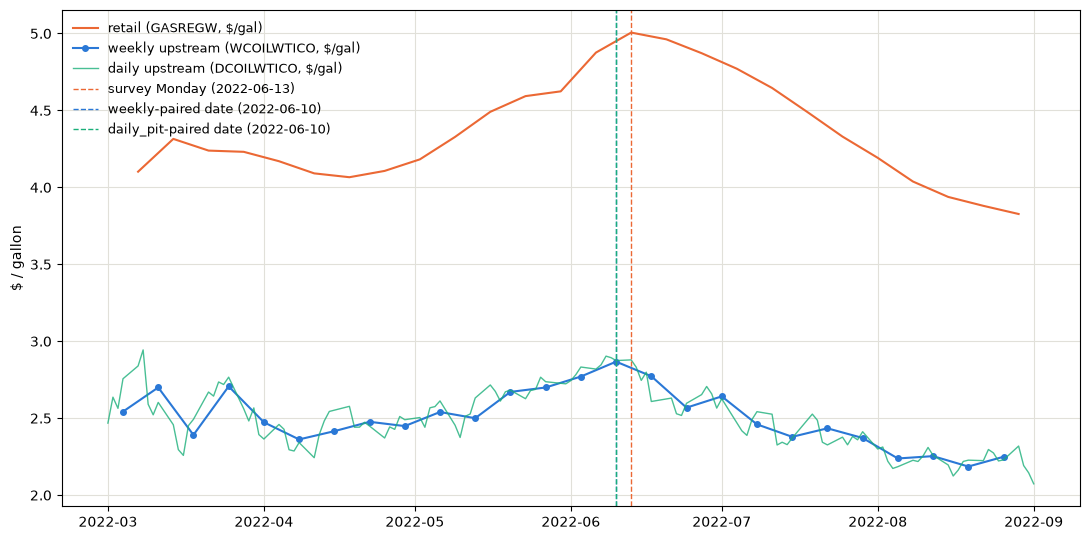

In [12]:
WINDOW_START = pd.Timestamp("2022-03-01")
WINDOW_END = pd.Timestamp("2022-09-01")

retail_window = retail[(retail["date"] >= WINDOW_START) & (retail["date"] <= WINDOW_END)]
weekly_upstream_window = weekly_upstream[(weekly_upstream["date"] >= WINDOW_START) & (weekly_upstream["date"] <= WINDOW_END)]
daily_upstream_window = daily_upstream[(daily_upstream["date"] >= WINDOW_START) & (daily_upstream["date"] <= WINDOW_END)]

weekly_marked_row = weekly[weekly["date"] == EXAMPLE_DATE].iloc[0]
daily_pit_marked_row = daily_pit[daily_pit["date"] == EXAMPLE_DATE].iloc[0]

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(retail_window["date"], retail_window["value"], color=COLOR_RETAIL, linewidth=1.5, label="retail (GASREGW, $/gal)")
ax.plot(weekly_upstream_window["date"], weekly_upstream_window["value"], color=COLOR_WEEKLY, linewidth=1.5, marker="o", markersize=4, label="weekly upstream (WCOILWTICO, $/gal)")
ax.plot(daily_upstream_window["date"], daily_upstream_window["value"], color=COLOR_DAILY_PIT, linewidth=1, alpha=0.8, label="daily upstream (DCOILWTICO, $/gal)")

ax.axvline(weekly_marked_row["date"], color=COLOR_RETAIL, linestyle="--", linewidth=1, label=f"survey Monday ({weekly_marked_row['date'].date()})")
ax.axvline(weekly_marked_row["upstream_date"], color=COLOR_WEEKLY, linestyle="--", linewidth=1, label=f"weekly-paired date ({weekly_marked_row['upstream_date'].date()})")
ax.axvline(daily_pit_marked_row["upstream_date"], color=COLOR_DAILY_PIT, linestyle="--", linewidth=1, label=f"daily_pit-paired date ({daily_pit_marked_row['upstream_date'].date()})")

ax.set_ylabel("$ / gallon")
ax.grid(True, color="#e1e0d9")
ax.legend(loc="upper left", frameon=False, fontsize=9)

plt.tight_layout()
plt.show()

On this particular example week the weekly-paired and daily_pit-paired dates coincide (both 2022-06-10) — the two dashed lines overlap rather than showing as visibly distinct. That's not a plotting bug: it's the ordinary case, true for 831 of 865 weeks (see section 3) — the two alignments only diverge in the 34 holiday weeks listed there. Re-running section 1/5 with `EXAMPLE_DATE` set to one of those 34 dates (e.g. `2022-04-18`, a Good Friday week) would show the two lines actually separate.